In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')
    
import numpy as np
from functools import partial

from scipy.integrate import quad

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from mcp_boltzmann.plasma import m_gam_2, m_B_2

## Set Mass and Millicharge

In [3]:
m_mcp = 10*1e3
Q = 1e-9

In [4]:
160*1e3

160000.0

In [5]:
def alpha_of_T(T):
    alpha_0 = 1/137
    m_e = 0.511
    A = np.exp(5/3)

    num = alpha_0
    den = 1 - (alpha_0/(3*np.pi))*np.log(T**2/A*m_e**2)

    return num/den

In [6]:
137*alpha_of_T(1e-11)

0.9600952704769778

In [7]:
1/alpha_of_T(100*1e3)

134.87619263084656

# Compute plasma mass of photon

In [8]:
T_sm_grid = np.geomspace(1e-3, 1e6, 1000)
mg2 = m_gam_2(T_sm_grid)
mgam_grid = np.sqrt(mg2)
mgam_interp = interp1d(T_sm_grid, mgam_grid, bounds_error=False, fill_value=(0, mgam_grid[-1]))

def mgamma_thermal(T_sm, T_ds):
    return mgam_interp(T_sm)


T_B_grid = np.geomspace(1e5, 1e8, 100)
mB2 = m_B_2(T_B_grid)
mB_grid = np.sqrt(mB2)
mB_interp = interp1d(T_B_grid, mB_grid, bounds_error=False, fill_value=(0, mB_grid[-1]))

def m_B_thermal(T_sm, T_ds):
    return mB_interp(T_sm)
    

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/plasma.py:45: RuntimeWarning: overflow encountered in exp
  return np.sqrt(z**2 - x**2)/(np.exp(z)+1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/plasma.py:48: RuntimeWarning: overflow encountered in exp
  return np.sqrt(z**2 - x**2)/(np.exp(z)-1)


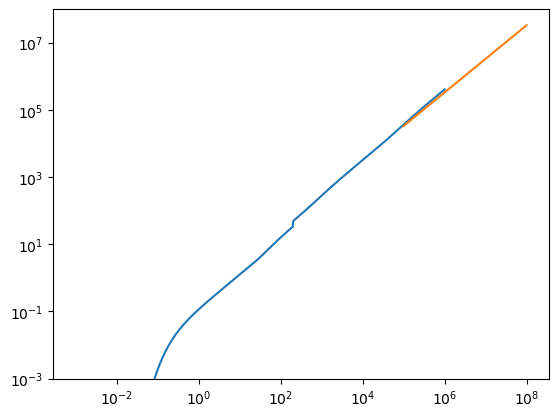

In [9]:
plt.plot(T_sm_grid, mgam_grid)
plt.plot(T_B_grid, mB_grid)

plt.ylim(1e-3, 1e8)

plt.xscale('log')
plt.yscale('log')
plt.show()

# Elastic Scattering Collision Integral

## Calculation of quantum statistics corrections to MB collision integrals

In [10]:
#load up some CSVs of 2206.13530 Figure 9 to compare
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

shelton_f9_FD = load_csv('../input/fig/2206.13530_fig9_right_Fermi-Dirac.csv')
shelton_f9_BE = load_csv('../input/fig/2206.13530_fig9_right_Bose-Einstein.csv')
shelton_f9_MCP = load_csv('../input/fig/2206.13530_fig9_right_MCP Model.csv')

### Compare to the right panel of Figure 9 of 2206.13530

### Compare to the left panel of Figure 8 of 2206.13530

In [11]:
alpha = 1.0/137.0
e = np.sqrt(4*alpha*np.pi)

s2_theta_w = 0.22339 
c2_theta_w = 1-s2_theta_w

q_e = -1
q_u = 2/3
q_d = -1/3
q_s = -1/3
q_c = 2/3   
q_b = -1/3
q_t = 2/3

#hyper charges, using convention that Q = T3 + Y 
Y_u_l = 1/6
Y_u_r = 2/3
Y_d_l = 1/6
Y_d_r = -1/3
Y_H = 1/2

Y_e_l = -1/2
Y_nu_l = -1/2
Y_e_R = -1


In [12]:
#factor to scale the coeeficients by
pref_lept = 4*16*np.pi*e**4
pref_lq = 4*3*16*np.pi*e**4*(q_u**2 + q_d**2)
pref_strange = 4*3*16*np.pi*e**4*(q_s**2)
pref_charm = 4*3*16*np.pi*e**4*(q_c**2)
pref_bot = 4*3*16*np.pi*e**4*(q_b**2)
pref_top = 4*3*16*np.pi*e**4*(q_t**2)
pref_higgs = 0.0

In [13]:
pref_e_l = Y_e_l**2/(2*c2_theta_w**2)
pref_e_r = Y_e_R**2/(2*c2_theta_w**2)

pref_u_l = Y_u_l**2/(2*c2_theta_w**2)
pref_u_r = Y_u_r**2/(2*c2_theta_w**2)

pref_d_l = Y_d_l**2/(2*c2_theta_w**2)
pref_d_r = Y_d_r**2/(2*c2_theta_w**2)

pref_nu_l = Y_nu_l**2/(2*c2_theta_w**2)

#4 higgs degrees of freedom
pref_higgs_EW = 4*4*np.pi*(e**4/c2_theta_w**2)

pref_lept_EW = 4*16*np.pi*e**4*(pref_e_l + pref_e_r)
pref_u_EW = 4*3*16*np.pi*e**4*(pref_u_l + pref_u_r)
pref_d_EW = 4*3*16*np.pi*e**4*(pref_d_l + pref_d_r)

pref_nu_EW = 4*3*16*np.pi*e**4*pref_nu_l #it really is 4 here because this is summing over all combinations of particles/antiparticles

pref_lq_EW = (pref_u_EW + pref_d_EW)
pref_charm_EW = pref_u_EW
pref_strange_EW = pref_d_EW
pref_top_EW = pref_u_EW
pref_bot_EW = pref_d_EW

#### Definitions of scattering integrals

In [14]:
import mcp_boltzmann.elastic_scattering as elscat
def _setup_int_ff(m_mcp, m_f, mgam):
    elcol = elscat.ElasticCollisionIntegral(m_f, m_mcp, mgam, zeta_a=1, zeta_b=1)
    elcol.matrix_element_nml['c222'] = 0.75
    elcol.matrix_element_nml['c202'] = -0.25
    elcol.matrix_element_nml['c022'] = -0.25
    elcol.matrix_element_nml['c002'] = 0.75
    elcol.matrix_element_nml['c001'] = m_mcp**2 + m_f**2
    elcol.matrix_element_nml['c201'] = m_mcp**2
    elcol.matrix_element_nml['c021'] = m_f**2
    elcol.matrix_element_nml['c000'] = 4*m_f**2*m_mcp**2
    
    return elcol
    
def _setup_int_hh(m_mcp, m_B):
    elcol = elscat.ElasticCollisionIntegral(0.0, m_mcp, m_B, zeta_a=-1, zeta_b=1)
    elcol.matrix_element_nml['c222'] = 0.75
    elcol.matrix_element_nml['c202'] = -0.25
    elcol.matrix_element_nml['c022'] = -0.25
    elcol.matrix_element_nml['c002'] = -0.25
    elcol.matrix_element_nml['c201'] = m_mcp**2
    elcol.matrix_element_nml['c001'] = -m_mcp**2
    
    return elcol

def setup_coulomb_integrals(m_mcp, mgam):
    m_e = 0.511
    m_mu = 105
    m_tau = 1776
    m_s = 95
    m_c = 1270
    m_b = 4180
    m_t = 172.76*1e3
    
    coulomb_e = _setup_int_ff(m_mcp, m_e, mgam)
    coulomb_mu = _setup_int_ff(m_mcp, m_mu, mgam)
    coulomb_tau = _setup_int_ff(m_mcp, m_tau, mgam)   
    
    coulomb_lq = _setup_int_ff(m_mcp, 0.0, mgam)   
    coulomb_strange = _setup_int_ff(m_mcp, m_s, mgam)   
    coulomb_charm = _setup_int_ff(m_mcp, m_c, mgam)  
    coulomb_bottom = _setup_int_ff(m_mcp, m_b, mgam)  
    coulomb_top = _setup_int_ff(m_mcp, m_t, mgam)
    
    coulomb_higgs = _setup_int_hh(m_mcp, mgam)
    
    return {
        "rate_e": coulomb_e, 
        "rate_mu": coulomb_mu, 
        "rate_tau": coulomb_tau, 
        "rate_lq": coulomb_lq, 
        "rate_strange": coulomb_strange,
        "rate_charm": coulomb_charm,
        "rate_bottom": coulomb_bottom,
        "rate_top": coulomb_top,
        "rate_higgs": coulomb_higgs
        } 

#### Compute Integrals 

In [15]:
T_range = m_mcp*np.geomspace(.01, 1e3, 100)
T_ratio = 0.35
T_EW = 160*1e3


res_e = np.zeros(len(T_range))
res_mu = np.zeros(len(T_range))
res_tau = np.zeros(len(T_range))
res_lq = np.zeros(len(T_range))
res_strange = np.zeros(len(T_range))
res_charm = np.zeros(len(T_range))
res_bot = np.zeros(len(T_range))
res_top = np.zeros(len(T_range))
res_higgs = np.zeros(len(T_range))
res_nu = np.zeros(len(T_range))

for (i, T) in enumerate(T_range):
    if T > T_EW:
        rate_funs = setup_coulomb_integrals(m_mcp, m_B_thermal)

        rate_int_e = rate_funs['rate_e']
        rate_int_mu = rate_funs['rate_mu']
        rate_int_tau = rate_funs['rate_tau']
        rate_int_lq = rate_funs['rate_lq']
        rate_int_strange = rate_funs['rate_strange']
        rate_int_charm = rate_funs['rate_charm']
        rate_int_bot = rate_funs['rate_bottom']
        rate_int_top = rate_funs['rate_top']
        rate_int_higgs = rate_funs['rate_higgs']

        e_rate = rate_int_e.compute_QS(T, T_ratio*T)[0] #save so we can reuse for neutrinos

        res_e[i] = pref_lept_EW*e_rate
        res_mu[i] = pref_lept_EW*rate_int_mu.compute_QS(T, T_ratio*T)[0]
        res_tau[i] = pref_lept_EW*rate_int_tau.compute_QS(T, T_ratio*T)[0]
        res_lq[i] = pref_lq_EW*rate_int_lq.compute_QS(T, T_ratio*T)[0]
        res_strange[i] = pref_strange_EW*rate_int_strange.compute_QS(T, T_ratio*T)[0]
        res_charm[i] = pref_charm_EW*rate_int_charm.compute_QS(T, T_ratio*T)[0]
        res_bot[i] = pref_bot_EW*rate_int_bot.compute_QS(T, T_ratio*T)[0]
        # res_top[i] = pref_top_EW*rate_int_top.compute_QS(T, T_ratio*T)[0]
        res_higgs[i] = pref_higgs_EW*rate_int_higgs.compute_QS(T, T_ratio*T)[0]
        res_top[i] = pref_top_EW*e_rate
        res_nu[i] = pref_nu_EW*e_rate
        
    else:
        rate_funs = setup_coulomb_integrals(m_mcp, mgamma_thermal)

        rate_int_e = rate_funs['rate_e']
        rate_int_mu = rate_funs['rate_mu']
        rate_int_tau = rate_funs['rate_tau']
        rate_int_lq = rate_funs['rate_lq']
        rate_int_strange = rate_funs['rate_strange']
        rate_int_charm = rate_funs['rate_charm']
        rate_int_bot = rate_funs['rate_bottom']
        rate_int_top = rate_funs['rate_top']
        rate_int_higgs = rate_funs['rate_higgs']

        res_e[i] = pref_lept*rate_int_e.compute_QS(T, T_ratio*T)[0]
        res_mu[i] = pref_lept*rate_int_mu.compute_QS(T, T_ratio*T)[0]
        res_tau[i] = pref_lept*rate_int_tau.compute_QS(T, T_ratio*T)[0]
        res_lq[i] = pref_lq*rate_int_lq.compute_QS(T, T_ratio*T)[0]
        res_strange[i] = pref_strange*rate_int_strange.compute_QS(T, T_ratio*T)[0]
        res_charm[i] = pref_charm*rate_int_charm.compute_QS(T, T_ratio*T)[0]
        res_bot[i] = pref_bot*rate_int_bot.compute_QS(T, T_ratio*T)[0]
        res_top[i] = pref_top*rate_int_top.compute_QS(T, T_ratio*T)[0]
        res_higgs[i] = 0.0 


/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/elastic_scattering.py:140: RuntimeWarning: overflow encountered in expm1
  -np.power(np.expm1(p0/T_b), -1)*np.power(-np.expm1(-p0/T_a), -1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/elastic_scattering.py:139: RuntimeWarning: overflow encountered in expm1
  +np.power(np.expm1(p0/T_a), -1)*np.power(-np.expm1(-p0/T_b), -1)


In [16]:
# shelton_f8_035 = load_csv('../input/fig/2206.13530_fig8_left_035.csv')
# shelton_f8_080 = load_csv('../input/fig/Ths_08Tsm.csv')

In [17]:
#10 GeV version
shelton_f8_035 = load_csv('../input/fig/2206.13530_fig8_right_coulomb_035.csv')

In [18]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate
from scipy.interpolate import LinearNDInterpolator


# m_mcp = 1.526e+05


# T_range = m_mcp*np.geomspace(.01, 1e3, 100)
# T_ratio = 0.35
# T_EW = 160*1e3
# Q = 1e-9

coulomb_m_2000 = load_tabulated_rate('../output/rates/coulomb/cluster/scan/mcp_coulomb_rate_m_10000.0_Q_1.npz')
coulomb_m_2000_no_top = load_tabulated_rate('../output/rates/coulomb/cluster/notop/mcp_coulomb_rate_m_10000.0_Q_1.npz')

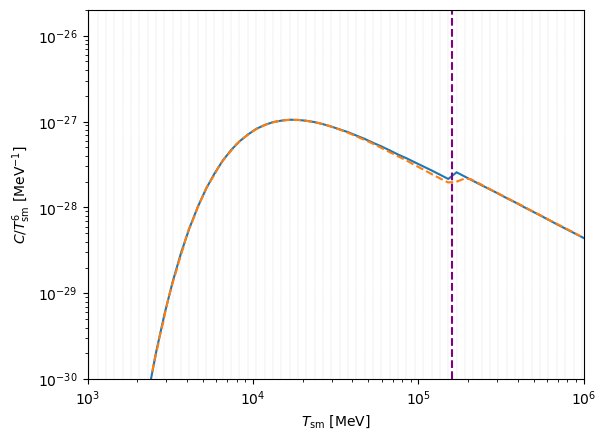

In [21]:
LQCD = 200
qed = Q**2*(
    res_e
   +res_mu
   +res_tau
)/T_range**6


qcd = Q**2*np.heaviside(T_range - LQCD, 0)*(
    (res_lq)/T_range**6 
  + res_strange/T_range**6 
  + res_charm/T_range**6
  + res_bot/T_range**6
  # + res_top/T_range**6*np.heaviside(T_range - T_EW, 0)
  + res_top/T_range**6
)

higgs = Q**2*res_higgs/T_range**6
neutrino = Q**2*res_nu/T_range**6

EW  = (higgs + neutrino)*np.heaviside(T_range - T_EW, 0)

eprime = 0.3

# dark_thomspon = C_thompson(T_range, T_ratio*T_range, m_mcp, Q, eprime)*np.heaviside(m_mcp - T_range, 0)

plt.plot(T_range, qed + qcd + EW)
# plt.plot(T_range, qed)
# plt.plot(T_range,  Q**2*res_top/T_range**6)


# plt.plot(T_range, qcd)
# plt.plot(T_range, EW)
# plt.plot(T_range, qed)
plt.axvline(T_EW, linestyle='dashed', color='purple')
plt.plot(*shelton_f8_035, linestyle='dashed')
# plt.plot(T_range, Q**2*coulomb_m_2000(T_range, 0.35*T_range)/T_range**6)
# plt.plot(T_range, Q**2*coulomb_m_2000_no_top(T_range, 0.35*T_range)/T_range**6)


# plt.plot(T_range, dark_thomspon/T_range**6,)
# plt.plot(*shelton_f8_080, linestyle='dashed')
plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'$T_{\rm sm}$ [MeV]')
plt.ylabel(r'$C/T^6_{\rm sm}$ [MeV$^{-1}$]')

plt.xlim(1e3, 1e6)
plt.ylim(1e-30, 2e-26)

plt.vlines(T_range, 1e-30, 2e-26, linestyle='dotted', color='black', linewidth=0.1)
plt.show()

In [20]:
LQCD = 200
# plt.plot(T_range, qcd, linestyle='none', marker='o')
plt.plot(T_range, 4*pref*(res)/T_range**6, label='electrons')
plt.plot(T_range, 4*pref*(res_mu)/T_range**6, label='muons')
plt.plot(T_range, 4*pref*(res_tau)/T_range**6, label='tauons')

plt.axvline(5*m_mu, linestyle='dashed')



plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'$T_{\rm sm}$ [MeV]')
plt.ylabel(r'$C/T^6_{\rm sm}$ [MeV$^{-1}$]')
plt.legend()

plt.xlim(1, 1e3)
plt.ylim(1e-28, 2e-24)

NameError: name 'pref' is not defined

### Comparison with Dark thompson scattering

In [ ]:
from mcp_boltzmann.distributions import rho_gam, nDM_FD

def C_thompson(T_sm, T_ds, m_mcp, Q, edark):
    c2_theta_w = 0.77661
    alpha_dark = edark**2/(4*np.pi)
    sigma_DT = (8*np.pi/3)*(alpha_dark/m_mcp)**2
    return 12*(Q**2/c2_theta_w**2)*sigma_DT*nDM_FD(T_ds, np.zeros_like(T_ds), m_mcp)*(rho_gam(T_sm) - rho_gam(T_ds))

In [ ]:
# plt.plot(T_range, qed + qcd, label='coulomb scattering')
# plt.plot(T_range, dark_thomspon/T_range**6, label='dark thomson scattering')

# plt.yscale('log')
# plt.xscale('log')
# plt.xlim(0, 10)

# plt.title(f'Scattering comparison; {m_mcp=} MeV; {eprime=}')


# plt.xlabel(r'$T_{\rm sm}$ [MeV]')
# plt.ylabel(r'$C/T^6_{\rm sm}$ [MeV$^{-1}$]')
# plt.legend()
# plt.show()

In [ ]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate
from scipy.interpolate import LinearNDInterpolator

In [ ]:
def coulomb_rate_m2000(Tgam, Tds, Q):
    return Q**2*(coulomb_m_2000(Tgam, Tds))

In [ ]:
T_range = np.geomspace(1e3, 1e6)
plt.plot(T_range, coulomb_rate_m2000(T_range, 0.35*T_range, Q)/T_range**6)
plt.plot(*shelton_fig8_right_coulomb)

plt.axvline(160*1e3, linestyle='dashed', color='purple')

plt.xscale('log')
plt.yscale('log')

plt.ylim(1e-30, 1e-26)